In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    if "baseline" in root.lower() or "lightweight" in root.lower():
        print(root)
        for f in files[:50]:
            print("  ", f)

/kaggle/input/notebooks/manuelcoelho7/lightweight-models
   model_schema.json
   metrics_lightweight.csv
   __results__.html
   dt_socrel_depth6.joblib
   dt_soc_light_depth6.pkl
   __notebook__.ipynb
   feature_cols.json
   __output__.json
   custom.css
/kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1
   model_schema.json
   __results__.html
   ann_socrel.joblib
   baseline_metrics.csv
   __notebook__.ipynb
   feature_cols.json
   __output__.json
   rf_socrel.joblib
   custom.css
/kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1/__results___files
   __results___9_1.png
   __results___9_2.png
   __results___11_2.png
   __results___11_1.png


In [2]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CSV_PATH = "/kaggle/input/datasets/manuelcoelho7/log-001/log_001.csv"

BASELINE_DIR = "/kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1"
LIGHT_DIR    = "/kaggle/input/notebooks/manuelcoelho7/lightweight-models"

print("CSV_PATH:", CSV_PATH)
print("BASELINE_DIR exists?", os.path.exists(BASELINE_DIR))
print("LIGHT_DIR exists?", os.path.exists(LIGHT_DIR))


CSV_PATH: /kaggle/input/datasets/manuelcoelho7/log-001/log_001.csv
BASELINE_DIR exists? True
LIGHT_DIR exists? True


In [3]:
def read_csv_robust(path):
    # encontra a primeira linha que começa com "t_s,"
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.read().splitlines()

    header_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("t_s,"):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError("Não encontrei header 't_s,...' no CSV.")

    # read_csv a partir do header
    from io import StringIO
    s = "\n".join(lines[header_idx:])
    df = pd.read_csv(StringIO(s))
    return df

df = read_csv_robust(CSV_PATH)

print("Colunas:", df.columns.tolist())
print("Linhas:", len(df))
display(df.head(3))


Colunas: ['t_s', 'Vbus_V', 'Vshunt_mV', 'I_mA', 'P_mW', 'Vmeas_V', 'Vbat_V', 'T_C', 'SoC', 'SOC0_OCV', 'Ah_acc', 'SoC_max', 'Vcell_max_V', 'MAX_ok']
Linhas: 7702


,t_s,Vbus_V,Vshunt_mV,I_mA,P_mW,Vmeas_V,Vbat_V,T_C,SoC,SOC0_OCV,Ah_acc,SoC_max,Vcell_max_V,MAX_ok
0,0.000,3.656,35.99,359.7,1318.0,1.9064,3.8128,22.5,0.61725,0.61725,0.000000,0.601094,3.8663,1
1,0.537,3.656,35.99,359.9,1318.0,1.9056,3.8113,22.5,0.61723,0.61725,0.000054,0.601094,3.8675,1
2,1.073,3.652,35.97,360.0,1314.0,1.9060,3.8120,22.5,0.61721,0.61725,0.000107,0.601094,3.8650,1


In [4]:
# parâmetros do teu ensaio
C_AH = 2.6

# garantir numéricos
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["t_s", "Vbat_V", "I_mA", "T_C"]).copy()
df = df.sort_values("t_s").reset_index(drop=True)

# dt (s)
df["dt_s"] = df["t_s"].diff()
df = df[(df["dt_s"].isna()) | (df["dt_s"] > 0)].copy()
df["dt_s"] = df["dt_s"].fillna(0)

# Corrente: no Dhakal, corrente de descarga costuma ser negativa.
# Detetar sinal ignorando repouso (~0 mA)
I = df["I_mA"].astype(float).values
I_THRESH_mA = 30
mask = np.abs(I) > I_THRESH_mA

i_med = np.median(I[mask]) if mask.sum() > 10 else np.median(I)
SIGN_TO_DHAKAL = -1 if i_med > 0 else 1

df["current_A_dhakal"] = (df["I_mA"] / 1000.0) * SIGN_TO_DHAKAL
df["voltage_V"] = df["Vbat_V"]
df["temp_C"]    = df["T_C"]

# SoC0 para referência offline
if "SOC0_OCV" in df.columns and df["SOC0_OCV"].notna().any():
    soc0_used = float(df["SOC0_OCV"].dropna().iloc[0])
elif "SoC" in df.columns and df["SoC"].notna().any():
    soc0_used = float(df["SoC"].dropna().iloc[0])
else:
    soc0_used = 1.0

# coulomb offline
I_dis_A = -df["current_A_dhakal"]             # positivo em descarga
dAh = I_dis_A * (df["dt_s"] / 3600.0)
df["Ah_acc_offline"] = dAh.cumsum()
df["SoC_ref"] = np.clip(soc0_used - df["Ah_acc_offline"] / C_AH, 0, 1)

print("SIGN_TO_DHAKAL:", SIGN_TO_DHAKAL, "(+1 mantém; -1 inverte)")
print("soc0_used:", soc0_used)
display(df[["t_s","Vbat_V","I_mA","T_C","SoC_ref"]].head(5))
print("SoC_ref min/max:", df["SoC_ref"].min(), df["SoC_ref"].max())
print("Ah_acc_offline max:", df["Ah_acc_offline"].max())
print("I_mA min/max:", df["I_mA"].min(), df["I_mA"].max())


SIGN_TO_DHAKAL: -1 (+1 mantém; -1 inverte)
soc0_used: 0.61725


,t_s,Vbat_V,I_mA,T_C,SoC_ref
0,0.000,3.8128,359.7,22.50,0.617250
1,0.537,3.8113,359.9,22.50,0.617229
2,1.073,3.8120,360.0,22.50,0.617209
3,1.610,3.8105,360.0,22.50,0.617188
4,2.146,3.8098,360.0,22.56,0.617167


SoC_ref min/max: 0.46253081486111103 0.61725
Ah_acc_offline max: 0.40226988136111125
I_mA min/max: 325.4 360.0


df_eval OK: (7702, 20)


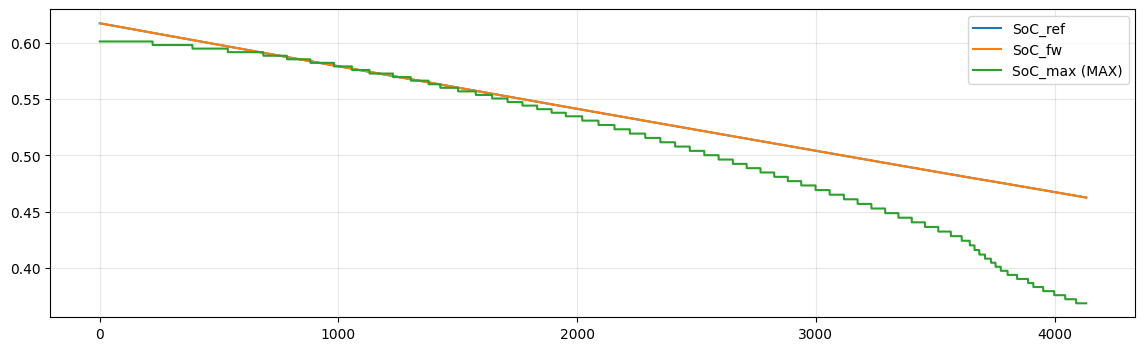

MAE SoC_fw vs SoC_ref: 2.5694674807088386e-06
MAE SoC_max vs SoC_ref: 0.0230398676059567
SoC_ref min/max: 0.46253081486111103 0.61725
Ah_acc_offline max: 0.40226988136111125
I_mA min/max: 325.4 360.0

Resumo rápido:


,Vbat_V,I_mA,T_C,SoC_ref,SoC
count,7702.000000,7702.000000,7702.000000,7702.000000,7702.000000
mean,3.716771,350.455972,22.545806,0.539166,0.539165
std,0.060446,6.140921,0.094082,0.044707,0.044708
min,3.388500,325.400000,22.310000,0.462531,0.462530
25%,3.684000,346.600000,22.500000,0.500335,0.500335
50%,3.721800,351.600000,22.560000,0.538797,0.538800
75%,3.761800,355.300000,22.620000,0.577807,0.577805
max,3.812800,360.000000,22.750000,0.617250,0.617250


In [5]:
# MAX17048
df_eval = df.copy()
print("df_eval OK:", df_eval.shape)
if "SoC_max" in df_eval.columns and df_eval["SoC_max"].notna().any():
    df_eval["SoC_max_01"] = df_eval["SoC_max"]/100.0 if df_eval["SoC_max"].max() > 1.5 else df_eval["SoC_max"]

    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error

    plt.figure(figsize=(14,4))
    plt.plot(df_eval["t_s"], df_eval["SoC_ref"], label="SoC_ref")
    plt.plot(df_eval["t_s"], df_eval["SoC"], label="SoC_fw")
    plt.plot(df_eval["t_s"], df_eval["SoC_max_01"], label="SoC_max (MAX)")
    plt.grid(True, alpha=0.3); plt.legend(); plt.show()

    print("MAE SoC_fw vs SoC_ref:", mean_absolute_error(df_eval["SoC_ref"], df_eval["SoC"]))
    print("MAE SoC_max vs SoC_ref:", mean_absolute_error(df_eval["SoC_ref"], df_eval["SoC_max_01"]))
else:
    print("CSV não tem SoC_max.")
df_eval = df.copy()
print("SoC_ref min/max:", df_eval["SoC_ref"].min(), df_eval["SoC_ref"].max())
print("Ah_acc_offline max:", df_eval["Ah_acc_offline"].max())
print("I_mA min/max:", df_eval["I_mA"].min(), df_eval["I_mA"].max())

print("\nResumo rápido:")
display(df_eval[["Vbat_V","I_mA","T_C","SoC_ref","SoC"]].describe())


In [6]:
# derivadas (por tempo)
dt = df["dt_s"].replace(0, np.nan)
df["dv_dt"] = df["voltage_V"].diff() / dt
df["di_dt"] = df["current_A_dhakal"].diff() / dt

df["dv_dt"] = df["dv_dt"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
df["di_dt"] = df["di_dt"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# no treino, "current" estava em A e "temperature" em ºC
df_features = pd.DataFrame({
    "voltage": df["voltage_V"].astype("float32"),
    "current": df["current_A_dhakal"].astype("float32"),
    "temperature": df["temp_C"].astype("float32"),
    "dv_dt": df["dv_dt"].astype("float32"),
    "di_dt": df["di_dt"].astype("float32"),
})

# --- alinhamento ESSENCIAL ---
valid_idx = df_features.dropna().index
df_features = df_features.loc[valid_idx].copy()
df_eval = df.loc[valid_idx].copy()

display(df_features.head(3))
print("[INFO] Linhas totais:", len(df), "| Linhas válidas p/ modelo:", len(df_eval))


,voltage,current,temperature,dv_dt,di_dt
0,3.8128,-0.3597,22.5,0.000000,0.000000
1,3.8113,-0.3599,22.5,-0.002793,-0.000372
2,3.8120,-0.3600,22.5,0.001306,-0.000187


[INFO] Linhas totais: 7702 | Linhas válidas p/ modelo: 7702


In [7]:
def eval_and_plot(df_eval, y_true_col, y_pred_col, title_prefix="Modelo"):
    y_true = df_eval[y_true_col].to_numpy()
    y_pred = df_eval[y_pred_col].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {title_prefix} ===")
    print(f"MAE : {mae:.5f}")
    print(f"RMSE: {rmse:.5f}")
    print(f"R²  : {r2:.5f}")

    # SoC vs tempo (alinhado)
    plt.figure(figsize=(14,4))
    plt.plot(df_eval["t_s"], y_true, linewidth=2, label="SoC_ref (offline)")
    plt.plot(df_eval["t_s"], y_pred, linewidth=2, label="SoC_pred (modelo)")
    plt.xlabel("Tempo (s)"); plt.ylabel("SoC")
    plt.title(f"{title_prefix} — SoC vs tempo")
    plt.grid(True, alpha=0.3); plt.legend()
    plt.show()

    # Parity
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, s=8, alpha=0.35)
    plt.plot([0,1],[0,1],"r--", linewidth=2)
    plt.xlabel("SoC_ref"); plt.ylabel("SoC_pred")
    plt.title(f"{title_prefix} — Parity")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"MAE": mae, "RMSE": rmse, "R2": r2}


✔ DT model carregado: DecisionTreeRegressor
✔ feature_cols: ['voltage', 'current', 'temperature', 'dv_dt', 'di_dt']

=== Lightweight — DT depth6 ===
MAE : 0.06852
RMSE: 0.09160
R²  : -3.19862


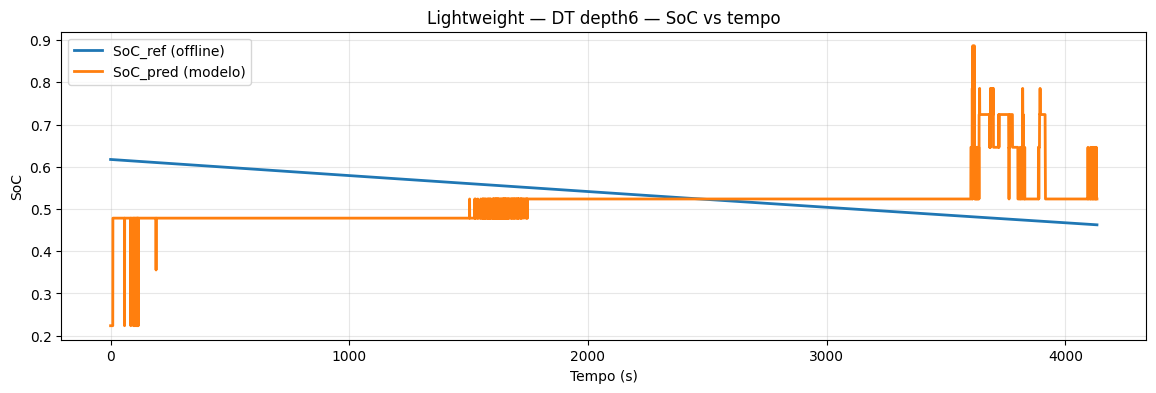

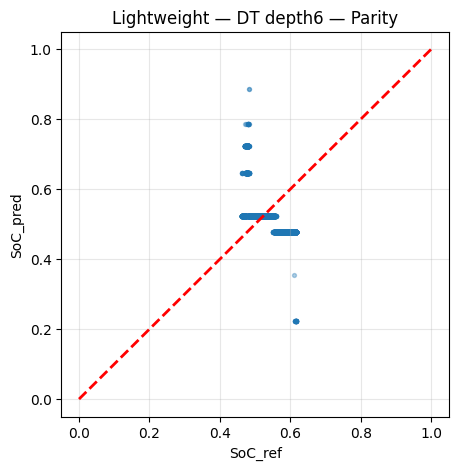

In [8]:
dt_path = os.path.join(LIGHT_DIR, "dt_socrel_depth6.joblib")
feat_path = os.path.join(LIGHT_DIR, "feature_cols.json")

if not (os.path.exists(dt_path) and os.path.exists(feat_path)):
    raise FileNotFoundError("Faltam ficheiros do lightweight no input. Verifica o caminho.")

dt_model = joblib.load(dt_path)

with open(feat_path, "r") as f:
    feature_cols = json.load(f)

print("✔ DT model carregado:", type(dt_model).__name__)
print("✔ feature_cols:", feature_cols)

X = df_features[feature_cols].copy()
y_pred_dt = dt_model.predict(X)

df_eval["SoC_pred_DT"] = np.clip(y_pred_dt, 0, 1)
m_dt = eval_and_plot(df_eval, "SoC_ref", "SoC_pred_DT", "Lightweight — DT depth6")


Procurando baseline outputs...
rf: True /kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1/rf_socrel.joblib
ann: True /kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1/ann_socrel.joblib
feat: True /kaggle/input/notebooks/manuelcoelho7/baseline-models-rf-ann-1/feature_cols.json

=== Baseline — Random Forest ===
MAE : 0.07903
RMSE: 0.10432
R²  : -4.44601


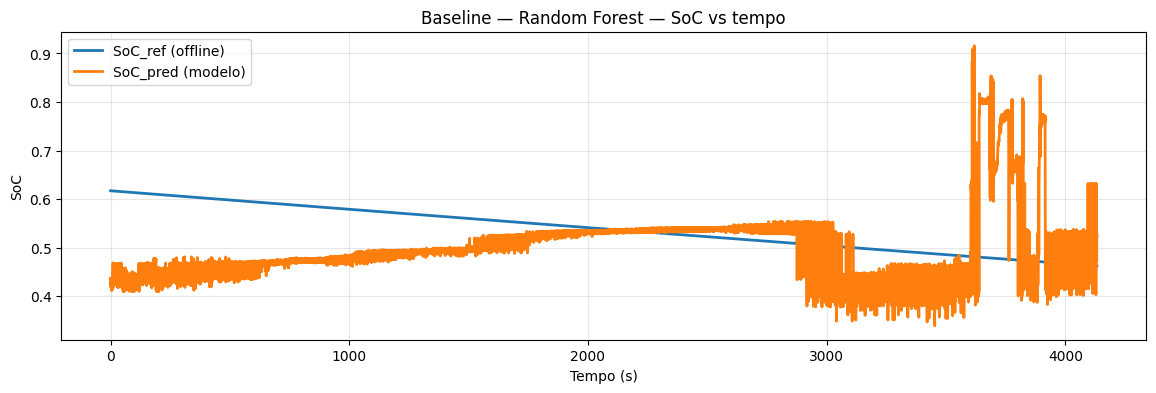

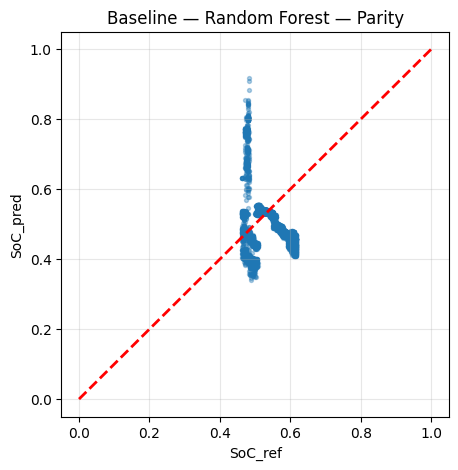


=== Baseline — ANN (MLP) ===
MAE : 0.09339
RMSE: 0.11436
R²  : -5.54460


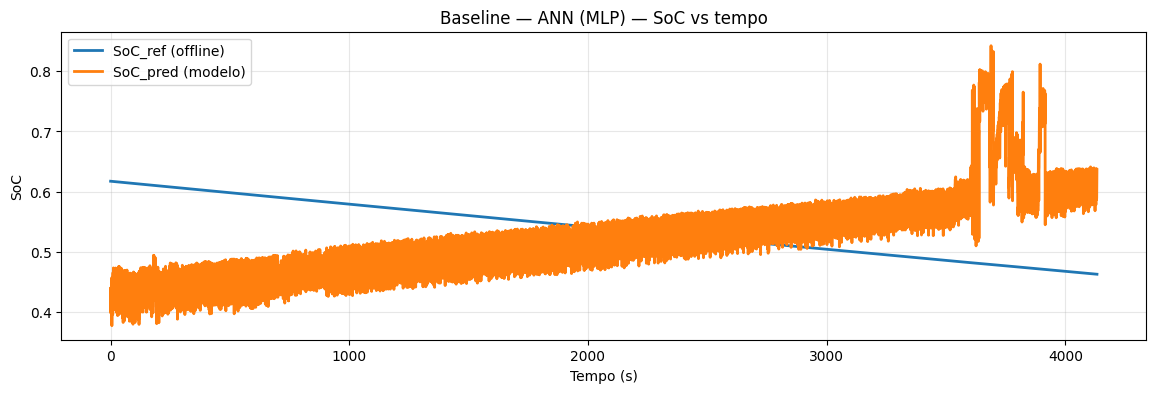

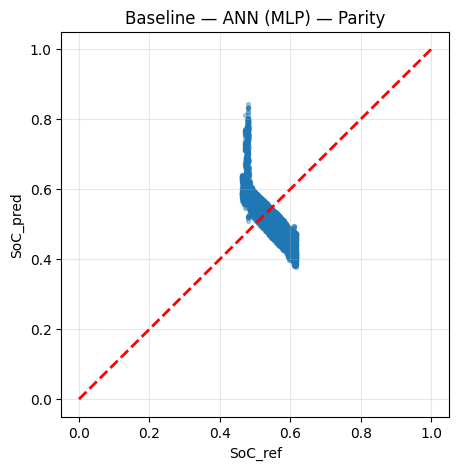

In [9]:
rf_path  = os.path.join(BASELINE_DIR, "rf_socrel.joblib")
ann_path = os.path.join(BASELINE_DIR, "ann_socrel.joblib")
feat_path_b = os.path.join(BASELINE_DIR, "feature_cols.json")

print("Procurando baseline outputs...")
print("rf:",  os.path.exists(rf_path),  rf_path)
print("ann:", os.path.exists(ann_path), ann_path)
print("feat:",os.path.exists(feat_path_b), feat_path_b)

if os.path.exists(rf_path) and os.path.exists(feat_path_b):
    rf_model = joblib.load(rf_path)
    with open(feat_path_b, "r") as f:
        feat_cols_b = json.load(f)

    Xb = df_features[feat_cols_b].copy()
    y_pred_rf = rf_model.predict(Xb)

    df_eval["SoC_pred_RF"] = np.clip(y_pred_rf, 0, 1)
    m_rf = eval_and_plot(df_eval, "SoC_ref", "SoC_pred_RF", "Baseline — Random Forest")
else:
    print("\n⚠️ Baseline RF não disponível como output no Input.")

if os.path.exists(ann_path) and os.path.exists(feat_path_b):
    ann_model = joblib.load(ann_path)
    with open(feat_path_b, "r") as f:
        feat_cols_b = json.load(f)

    Xb = df_features[feat_cols_b].copy()
    y_pred_ann = ann_model.predict(Xb)

    df_eval["SoC_pred_ANN"] = np.clip(y_pred_ann, 0, 1)
    m_ann = eval_and_plot(df_eval, "SoC_ref", "SoC_pred_ANN", "Baseline — ANN (MLP)")
else:
    print("\n⚠️ Baseline ANN não disponível como output no Input.")


In [10]:
rows = []
if "SoC_pred_DT" in df_eval.columns:
    rows.append({"model":"DT depth6", **m_dt})

if "SoC_pred_RF" in df_eval.columns:
    rows.append({"model":"RandomForest", **m_rf})

if "SoC_pred_ANN" in df_eval.columns:
    rows.append({"model":"ANN_MLP", **m_ann})

res = pd.DataFrame(rows)
display(res)


,model,MAE,RMSE,R2
0,DT depth6,0.068520,0.091600,-3.198617
1,RandomForest,0.079032,0.104324,-4.446012
2,ANN_MLP,0.093389,0.114363,-5.544602
